In [3]:
import pandas as pd

fertilize=pd.read_csv(r"C:\Users\jyija\Downloads\archive\FertilizerData.csv")
merge=pd.read_csv(r"C:\Users\jyija\Downloads\archive\MergeFileCrop.csv")

print(fertilize.head())
print(merge.head())




   Unnamed: 0         Crop   N   P   K   pH
0           0         rice  80  40  40  5.5
1           3        maize  80  40  20  5.5
2           5     chickpea  40  60  80  5.5
3          12  kidneybeans  20  60  20  5.5
4          13   pigeonpeas  20  60  20  5.5
   Unnamed: 0  temperature   humidity        ph    rainfall label
0           0    20.879744  82.002744  6.502985  202.935536  rice
1           1    21.770462  80.319644  7.038096  226.655537  rice
2           2    23.004459  82.320763  7.840207  263.964248  rice
3           3    26.491096  80.158363  6.980401  242.864034  rice
4           4    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
print(fertilize.columns)
print(merge.columns)

Index(['Unnamed: 0', 'Crop', 'N', 'P', 'K', 'pH'], dtype='str')
Index(['Unnamed: 0', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')


In [11]:
data_df = pd.merge(fertilize, merge, left_on="Crop", right_on="label", how="inner")
print(data_df.head())

   Unnamed: 0_x  Crop   N   P   K   pH  Unnamed: 0_y  temperature   humidity  \
0             0  rice  80  40  40  5.5             0    20.879744  82.002744   
1             0  rice  80  40  40  5.5             1    21.770462  80.319644   
2             0  rice  80  40  40  5.5             2    23.004459  82.320763   
3             0  rice  80  40  40  5.5             3    26.491096  80.158363   
4             0  rice  80  40  40  5.5             4    20.130175  81.604873   

         ph    rainfall label  
0  6.502985  202.935536  rice  
1  7.038096  226.655537  rice  
2  7.840207  263.964248  rice  
3  6.980401  242.864034  rice  
4  7.628473  262.717340  rice  


In [12]:

print(data_df.info())          # Data types and missing values
print(data_df.describe())      # Statistical summary
print(data_df.isnull().sum())  # Count missing values
print(data_df.duplicated().sum())  # Count duplicates

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0_x  2200 non-null   int64  
 1   Crop          2200 non-null   str    
 2   N             2200 non-null   int64  
 3   P             2200 non-null   int64  
 4   K             2200 non-null   int64  
 5   pH            2200 non-null   float64
 6   Unnamed: 0_y  2200 non-null   int64  
 7   temperature   2200 non-null   float64
 8   humidity      2200 non-null   float64
 9   ph            2200 non-null   float64
 10  rainfall      2200 non-null   float64
 11  label         2200 non-null   str    
dtypes: float64(5), int64(5), str(2)
memory usage: 206.4 KB
None
       Unnamed: 0_x            N            P            K           pH  \
count   2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean      48.681818    50.454545    45.681818    48.181818     5.409091   
std       32

In [14]:
print(data_df.isnull().sum())
print(data_df.info())

Unnamed: 0_x    0
Crop            0
N               0
P               0
K               0
pH              0
Unnamed: 0_y    0
temperature     0
humidity        0
ph              0
rainfall        0
label           0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0_x  2200 non-null   int64  
 1   Crop          2200 non-null   str    
 2   N             2200 non-null   int64  
 3   P             2200 non-null   int64  
 4   K             2200 non-null   int64  
 5   pH            2200 non-null   float64
 6   Unnamed: 0_y  2200 non-null   int64  
 7   temperature   2200 non-null   float64
 8   humidity      2200 non-null   float64
 9   ph            2200 non-null   float64
 10  rainfall      2200 non-null   float64
 11  label         2200 non-null   str    
dtypes: float64(5), int64(5), str(2)
memory usage: 206.4 KB
None


In [15]:
# 1. Remove duplicate index columns
data_df = data_df.drop(['Unnamed: 0_x', 'Unnamed: 0_y'], axis=1)

# 2. Remove duplicate 'pH' column (you have both 'pH' and 'ph')
data_df = data_df.drop(['ph'], axis=1)  # Keep 'pH' (uppercase)

# 3. Remove duplicate 'label' and 'Crop' columns (they represent the same thing)
data_df = data_df.drop(['label'], axis=1)  # Keep 'Crop'

# 4. Check your cleaned data
print(data_df.head())
print(data_df.info())
print(data_df.columns)

   Crop   N   P   K   pH  temperature   humidity    rainfall
0  rice  80  40  40  5.5    20.879744  82.002744  202.935536
1  rice  80  40  40  5.5    21.770462  80.319644  226.655537
2  rice  80  40  40  5.5    23.004459  82.320763  263.964248
3  rice  80  40  40  5.5    26.491096  80.158363  242.864034
4  rice  80  40  40  5.5    20.130175  81.604873  262.717340
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         2200 non-null   str    
 1   N            2200 non-null   int64  
 2   P            2200 non-null   int64  
 3   K            2200 non-null   int64  
 4   pH           2200 non-null   float64
 5   temperature  2200 non-null   float64
 6   humidity     2200 non-null   float64
 7   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None
Index(['Crop', 'N', 'P', 'K', 'pH', 'temperature', 'hu

In [20]:
import pandas as pd

# Save to CSV
data_df.to_csv('cleaned_data.csv', index=False)
print("✓ Saved as CSV: cleaned_data.csv")

✓ Saved as CSV: cleaned_data.csv


In [21]:
import pandas as pd
import os

# Save to Desktop
desktop_path = os.path.join(os.path.expanduser("~"), 'Desktop', 'cleaned_data.csv')
data_df.to_csv(desktop_path, index=False)
print(f"✓ Saved to Desktop: {desktop_path}")

# Save to Downloads
downloads_path = os.path.join(os.path.expanduser("~"), 'Downloads', 'cleaned_data.csv')
data_df.to_csv(downloads_path, index=False)
print(f"✓ Saved to Downloads: {downloads_path}")

# Save to Documents
documents_path = os.path.join(os.path.expanduser("~"), 'Documents', 'cleaned_data.csv')
data_df.to_csv(documents_path, index=False)
print(f"✓ Saved to Documents: {documents_path}")

✓ Saved to Desktop: C:\Users\jyija\Desktop\cleaned_data.csv
✓ Saved to Downloads: C:\Users\jyija\Downloads\cleaned_data.csv
✓ Saved to Documents: C:\Users\jyija\Documents\cleaned_data.csv


In [22]:
import pandas as pd

data_df = pd.read_csv('cleaned_data.csv')
print(data_df.head())
print(data_df.info())

   Crop   N   P   K   pH  temperature   humidity    rainfall
0  rice  80  40  40  5.5    20.879744  82.002744  202.935536
1  rice  80  40  40  5.5    21.770462  80.319644  226.655537
2  rice  80  40  40  5.5    23.004459  82.320763  263.964248
3  rice  80  40  40  5.5    26.491096  80.158363  242.864034
4  rice  80  40  40  5.5    20.130175  81.604873  262.717340
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         2200 non-null   str    
 1   N            2200 non-null   int64  
 2   P            2200 non-null   int64  
 3   K            2200 non-null   int64  
 4   pH           2200 non-null   float64
 5   temperature  2200 non-null   float64
 6   humidity     2200 non-null   float64
 7   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None


In [23]:
print(data_df.describe())
print(data_df['Crop'].value_counts())

                 N            P            K           pH  temperature  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.454545    45.681818    48.181818     5.409091    25.616244   
std      35.488826    31.891110    50.521281     0.576885     5.063749   
min      20.000000    10.000000    10.000000     4.000000     8.825675   
25%      20.000000    20.000000    20.000000     5.500000    22.769375   
50%      30.000000    40.000000    30.000000     5.500000    25.598693   
75%      80.000000    60.000000    50.000000     5.500000    28.561654   
max     120.000000   125.000000   200.000000     6.500000    43.675493   

          humidity     rainfall  
count  2200.000000  2200.000000  
mean     71.481779   103.463655  
std      22.263812    54.958389  
min      14.258040    20.211267  
25%      60.261953    64.551686  
50%      80.473146    94.867624  
75%      89.948771   124.267508  
max      99.981876   298.560117  
Crop
rice           100
mai

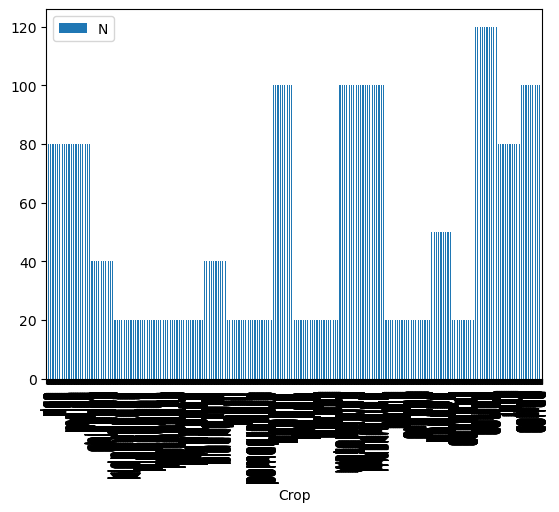

In [24]:
import matplotlib.pyplot as plt

data_df.plot(x='Crop', y='N', kind='bar')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = data_df.drop('Crop', axis=1)
y = LabelEncoder().fit_transform(data_df['Crop'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

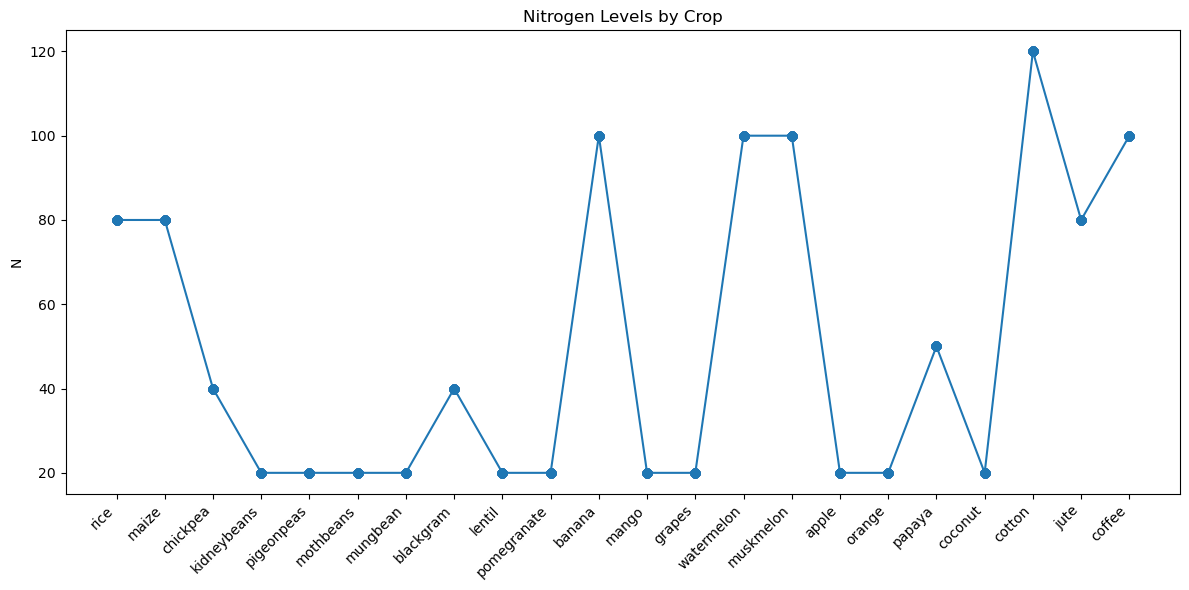

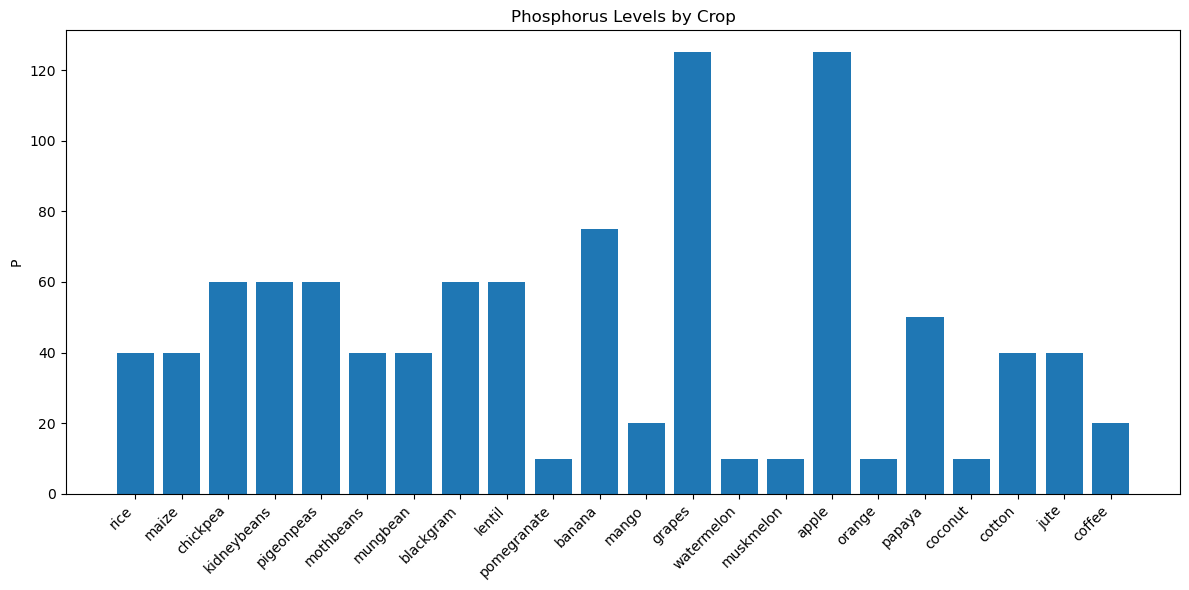

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

data_df = pd.read_csv('cleaned_data.csv')

# Line plot
plt.figure(figsize=(12, 6))
plt.plot(data_df['Crop'], data_df['N'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Nitrogen Levels by Crop')
plt.ylabel('N')
plt.tight_layout()
plt.show()

# Bar plot
plt.figure(figsize=(12, 6))
plt.bar(data_df['Crop'], data_df['P'])
plt.xticks(rotation=45, ha='right')
plt.title('Phosphorus Levels by Crop')
plt.ylabel('P')
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Load clean data
data_df = pd.read_csv('cleaned_data.csv')
# Prepare data
X = data_df.drop('Crop', axis=1)
y = LabelEncoder().fit_transform(data_df['Crop'])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Check accuracy
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 99.32%


MODEL EVALUATION METRICS

1. ACCURACY: 0.9932 (99.32%)
   → What percentage of predictions were correct?

2. PRECISION: 0.9940 (99.40%)
   → When model predicts a crop, how often is it correct?

3. RECALL: 0.9932 (99.32%)
   → Out of all actual crops, how many did model find?

4. F1 SCORE: 0.9931 (99.31%)
   → Balance between precision and recall

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.88      1.00      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00 

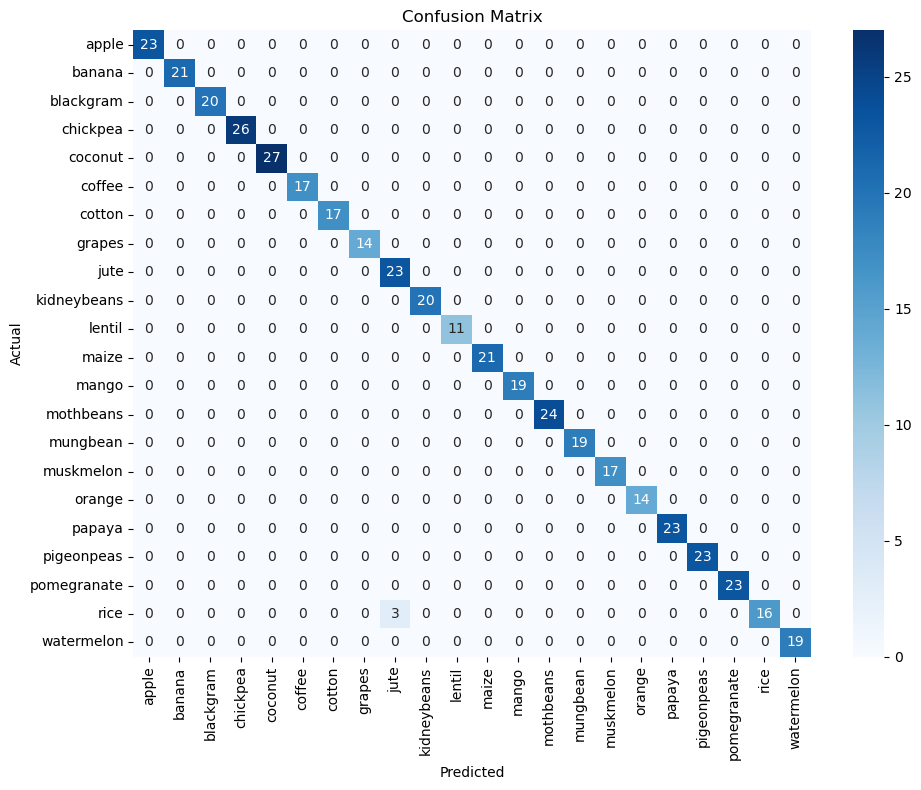

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data_df = pd.read_csv('cleaned_data.csv')

# Prepare
X = data_df.drop('Crop', axis=1)
y = LabelEncoder().fit_transform(data_df['Crop'])
encoder = LabelEncoder()
encoder.fit(data_df['Crop'])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# ============================================================
# CALCULATE ALL METRICS
# ============================================================

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\n1. ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("   → What percentage of predictions were correct?")

# Precision
precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
print(f"\n2. PRECISION: {precision:.4f} ({precision*100:.2f}%)")
print("   → When model predicts a crop, how often is it correct?")

# Recall
recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
print(f"\n3. RECALL: {recall:.4f} ({recall*100:.2f}%)")
print("   → Out of all actual crops, how many did model find?")

# F1 Score
f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
print(f"\n4. F1 SCORE: {f1:.4f} ({f1*100:.2f}%)")
print("   → Balance between precision and recall")

# Detailed Report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, predictions, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()